In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 4, 30)) & (dataset.data.index < datetime.datetime(2024, 12, 10)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [ ]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
apa = systemClasses.System(dataset=dataset, name="APA")
prm = systemClasses.System(dataset=dataset, name="PRM")
pipe = systemClasses.System(dataset=dataset, name="PIPE")
pp = systemClasses.System(dataset=dataset, name="PP")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")
ga1 = systemClasses.System(dataset=dataset, name="GA-1")
ga2 = systemClasses.System(dataset=dataset, name="GA-2")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:02<00:00,  5.18sensor/s]


ERROR: Channel (TE0120) not found


Initializing GA-1 Sensors: 100%|██████████| 18/18 [00:03<00:00,  5.39sensor/s]


In [5]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
apa.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")
prm.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pipe.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pp.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
hawai.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:09<00:00,  5.22sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 72.14sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:02<00:00,  7.86sensor/s]
Calibrating APA Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000: 100%|██████████| 16/16 [00:00<00:00, 77.73sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  6.14sensor/s]
Calibrating PRM Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 6/6 [00:00<00:00, 76.02sensor/s]
Equalizing PIPE Sensors:  92%|█████████▏| 11/12 [00:01<00:00,  6.36sensor/s]

ERROR: Channel (TE0120) not found


Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:02<00:00,  5.96sensor/s]
Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 12/12 [00:00<00:00, 61.47sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  6.03sensor/s]
Calibrating PP Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 2/2 [00:00<00:00, 94.59sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:03<00:00,  7.36sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 24/24 [00:00<00:00, 117.85sensor/s]


In [53]:
ambient = sensorClasses.Sensor(dataset=dataset, id=1011)
ambient.data = ambient.data.dropna()

/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/2276137066.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/2276137066.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/227

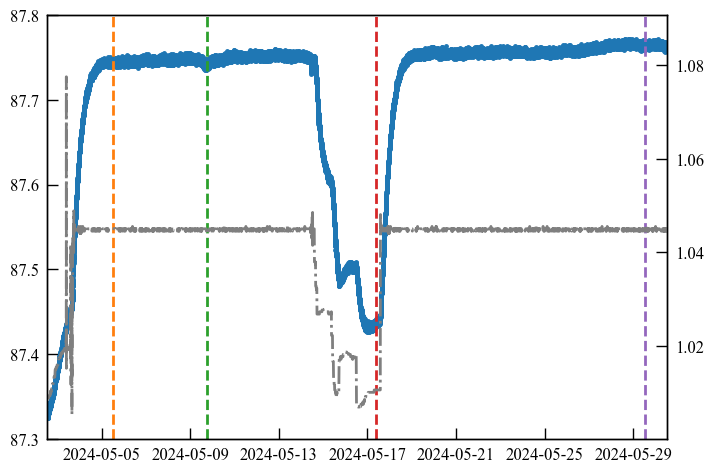

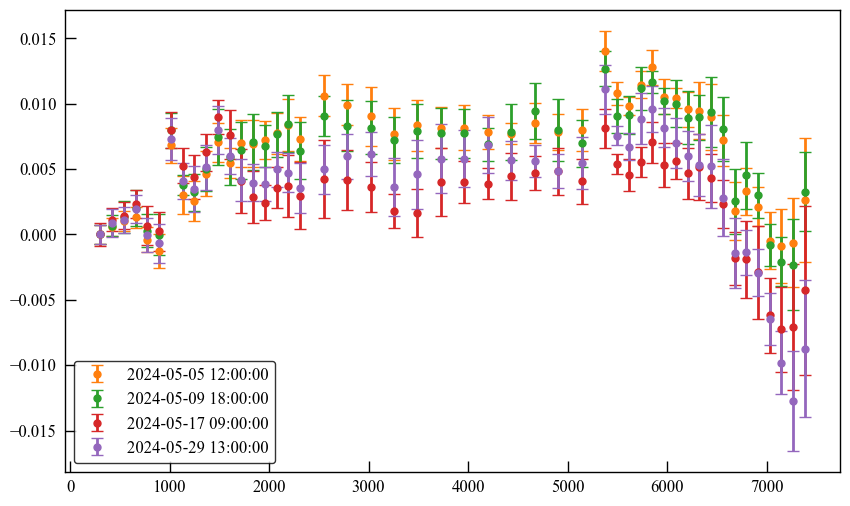

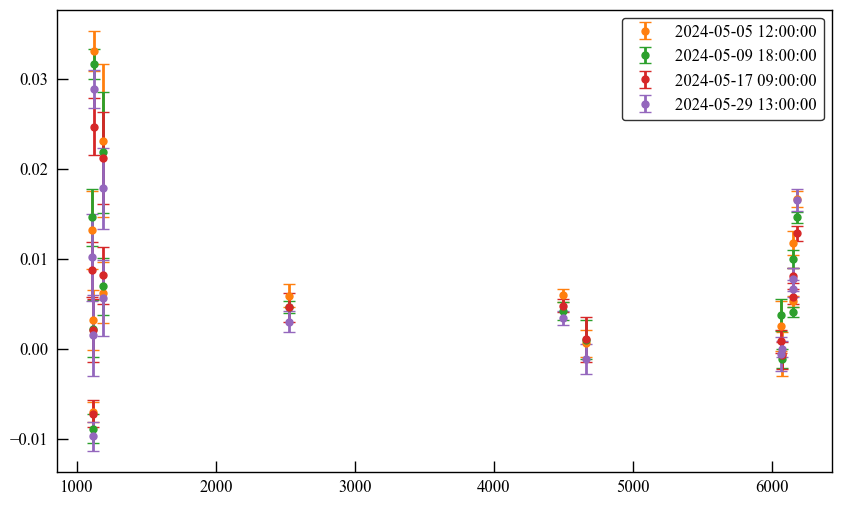

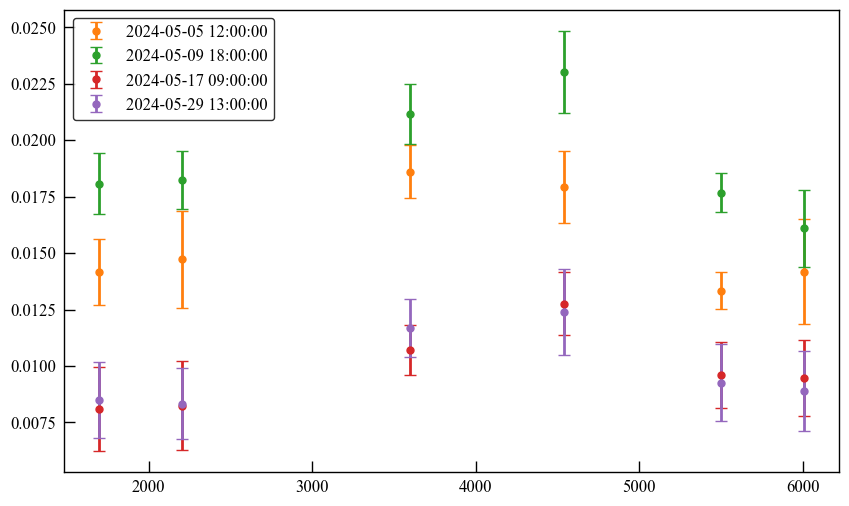

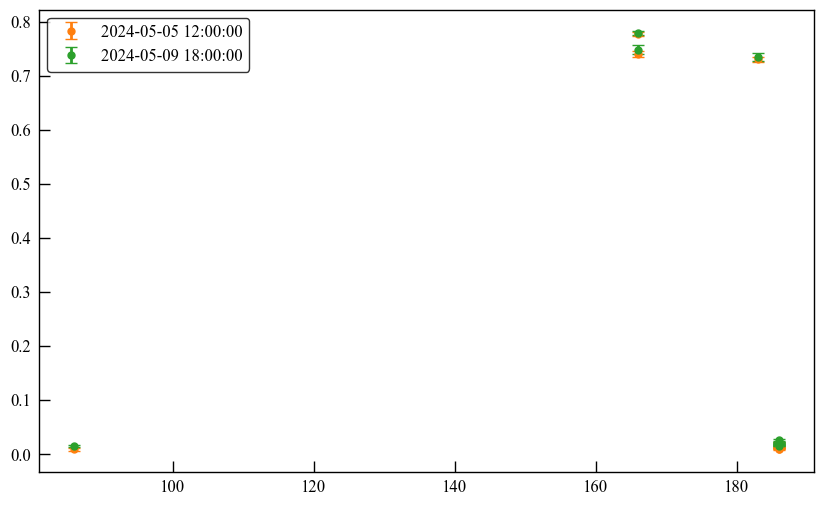

In [58]:
deltat = datetime.timedelta(minutes=15)
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5.5), sharex=True, sharey=True)
axes.plot(tgrad.sensors[39644].data.index.values, tgrad.sensors[39644].data.values, ".", label="TGRAD 39644", color="tab:blue")
axes.set_xlim(pd.Timestamp("2024-05-02 13:15:00"), pd.Timestamp("2024-05-30 13:00:00"))
axes.set_ylim(87.3,87.8)
t1, color1 = pd.Timestamp("2024-5-5 12:00:00"), "tab:orange"
axes.axvline(t1, color=color1, linestyle="--", label=f"{t1}")
t2, color2 = pd.Timestamp("2024-5-9 18:00:00"), "tab:green"
axes.axvline(t2, color=color2, linestyle="--", label=f"{t2}")
t3, color3 = pd.Timestamp("2024-5-17 9:00:00"), "tab:red"
axes.axvline(t3, color=color3, linestyle="--", label=f"{t3}")
t4, color4 = pd.Timestamp("2024-5-29 13:00:00"), "tab:purple"
axes.axvline(t4, color=color4, linestyle="--", label=f"{t4}")
axes2 = axes.twinx()
axes2.plot(ambient.data.index.values, ambient.data.values, "-.", label="Ambient", color="tab:gray")


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
profile = tgrad.profiles
zero1 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
zero2 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
profile = tgrad.profiles
zero3 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
profile = tgrad.profiles
zero4 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

####################### APA #######################
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
apa.makeProfiles(tini=t1, tend=t1 + deltat)
profile = apa.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

apa.makeProfiles(tini=t2, tend=t2 + deltat)
profile = apa.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

apa.makeProfiles(tini=t3, tend=t3 + deltat)
profile = apa.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

apa.makeProfiles(tini=t4, tend=t4 + deltat)
profile = apa.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
prm.makeProfiles(tini=t1, tend=t1 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

prm.makeProfiles(tini=t2, tend=t2 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

prm.makeProfiles(tini=t3, tend=t3 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

prm.makeProfiles(tini=t4, tend=t4 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
pipe.makeProfiles(tini=t1, tend=t1 + deltat)
profile = pipe.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

pipe.makeProfiles(tini=t2, tend=t2 + deltat)
profile = pipe.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

In [62]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
hawai.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
prm.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pipe.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pp.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
hawai.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:08<00:00,  5.78sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 84.70sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:03<00:00,  6.16sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 24/24 [00:00<00:00, 97.34sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:01<00:00,  5.14sensor/s]
Calibrating PRM Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 6/6 [00:00<00:00, 62.13sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:02<00:00,  4.95sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 12/12 [00:00<00:00, 46.15sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  5.53sensor/s]
Calibrating PP Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 2/2 [00:00<00:00, 69.03sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:03<00:00,  6.82sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 24/24 [00:00<00:00, 112.35sensor/s]


In [63]:
ambient = sensorClasses.Sensor(dataset=dataset, id=1021)
ambient.data = ambient.data.dropna()

/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/2485239541.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/2485239541.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/248

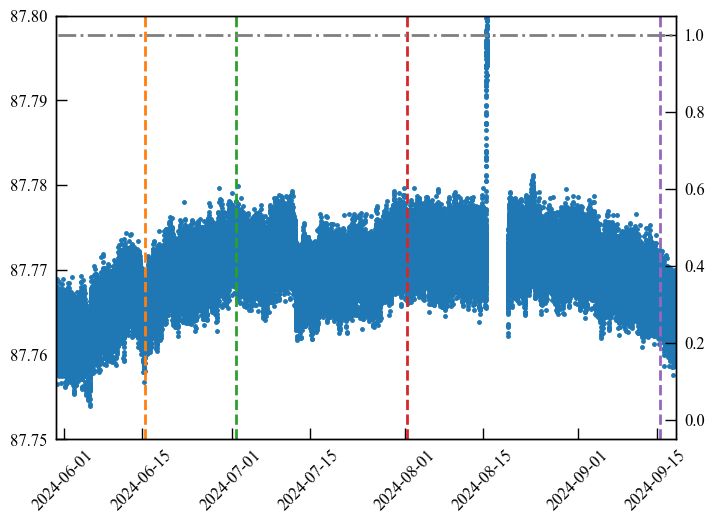

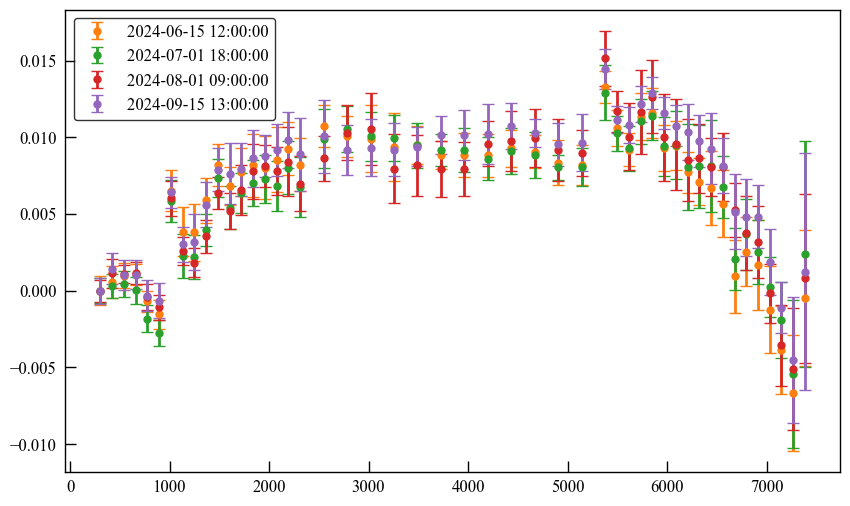

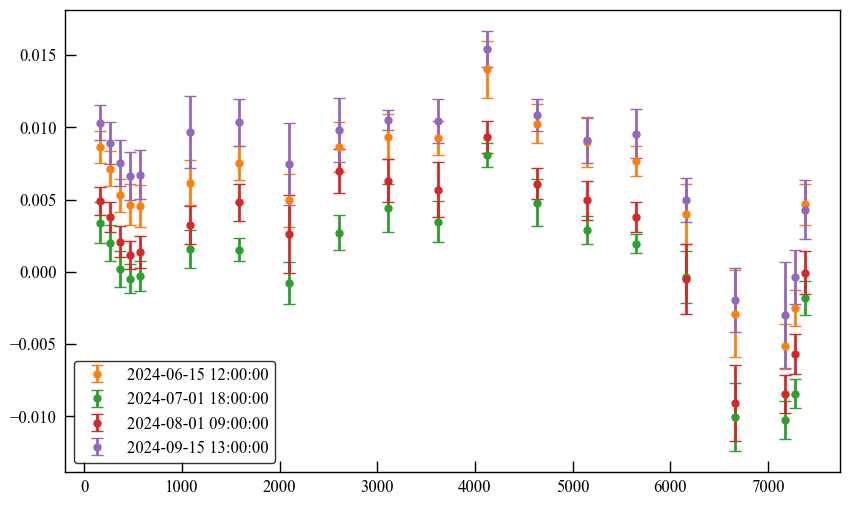

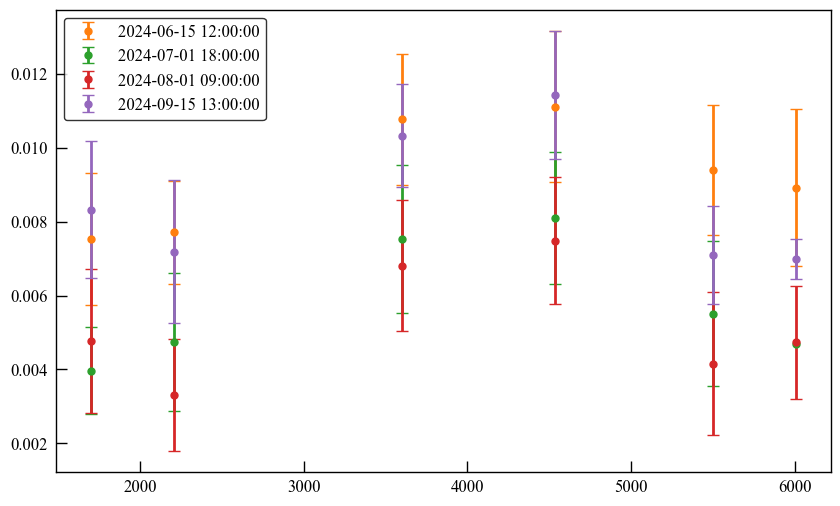

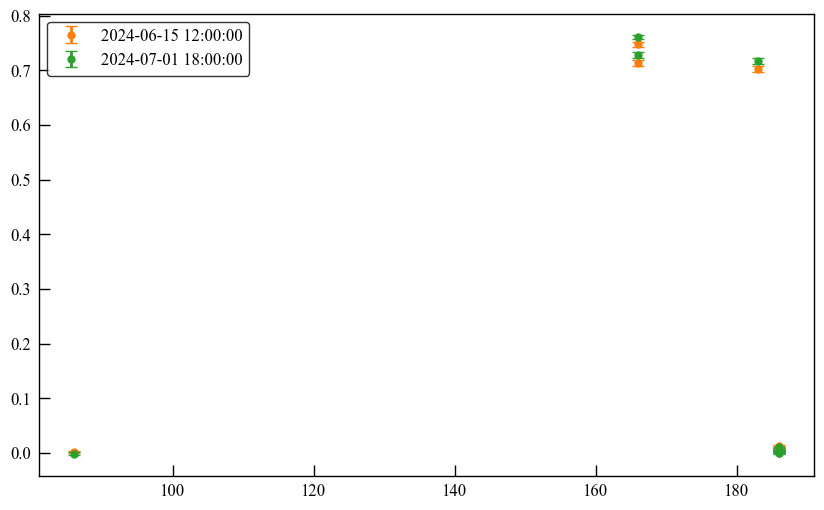

In [65]:
deltat = datetime.timedelta(minutes=15)
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5.5), sharex=True, sharey=True)
axes.plot(tgrad.sensors[39644].data.index.values, tgrad.sensors[39644].data.values, ".", label="TGRAD 39644", color="tab:blue")
axes.set_xlim(pd.Timestamp("2024-05-30 13:15:00"), pd.Timestamp("2024-09-18 10:40:00"))
axes.set_ylim(87.75,87.8)
t1, color1 = pd.Timestamp("2024-6-15 12:00:00"), "tab:orange"
axes.axvline(t1, color=color1, linestyle="--", label=f"{t1}")
t2, color2 = pd.Timestamp("2024-7-1 18:00:00"), "tab:green"
axes.axvline(t2, color=color2, linestyle="--", label=f"{t2}")
t3, color3 = pd.Timestamp("2024-8-1 9:00:00"), "tab:red"
axes.axvline(t3, color=color3, linestyle="--", label=f"{t3}")
t4, color4 = pd.Timestamp("2024-9-15 13:00:00"), "tab:purple"
axes.axvline(t4, color=color4, linestyle="--", label=f"{t4}")
axes2 = axes.twinx()
axes2.plot(ambient.data.index.values, ambient.data.values, "-.", label="Ambient", color="tab:gray")
axes.tick_params(axis='x', rotation=45)


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
profile = tgrad.profiles
zero1 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
zero2 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
profile = tgrad.profiles
zero3 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
profile = tgrad.profiles
zero4 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

####################### APA #######################
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
hawai.makeProfiles(tini=t1, tend=t1 + deltat)
profile = hawai.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

hawai.makeProfiles(tini=t2, tend=t2 + deltat)
profile = hawai.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

hawai.makeProfiles(tini=t3, tend=t3 + deltat)
profile = hawai.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

hawai.makeProfiles(tini=t4, tend=t4 + deltat)
profile = hawai.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
prm.makeProfiles(tini=t1, tend=t1 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

prm.makeProfiles(tini=t2, tend=t2 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

prm.makeProfiles(tini=t3, tend=t3 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

prm.makeProfiles(tini=t4, tend=t4 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
pipe.makeProfiles(tini=t1, tend=t1 + deltat)
profile = pipe.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

pipe.makeProfiles(tini=t2, tend=t2 + deltat)
profile = pipe.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

In [86]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
hawai.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
prm.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000")
pipe.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
apa.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:07<00:00,  6.18sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 100.39sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:03<00:00,  7.56sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 24/24 [00:00<00:00, 122.15sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  6.30sensor/s]
Calibrating PRM Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_ON_REC_OFF_HV_OFF_20240502_131500_20240502_133000: 100%|██████████| 6/6 [00:00<00:00, 112.34sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  6.18sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 12/12 [00:00<00:00, 118.39sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00,  9.07sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 16/16 [00:00<00:00, 109.97sensor/s]


In [87]:
ambient = sensorClasses.Sensor(dataset=dataset, id=1049)
ambient.data = ambient.data.dropna()

/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/592161871.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/592161871.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/59216

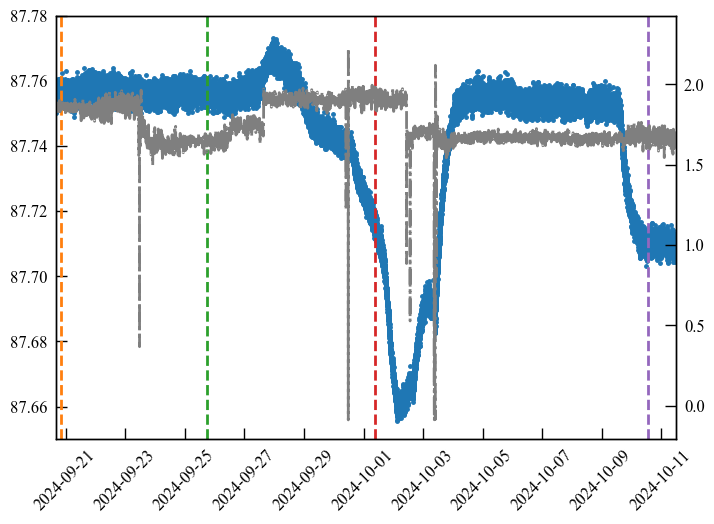

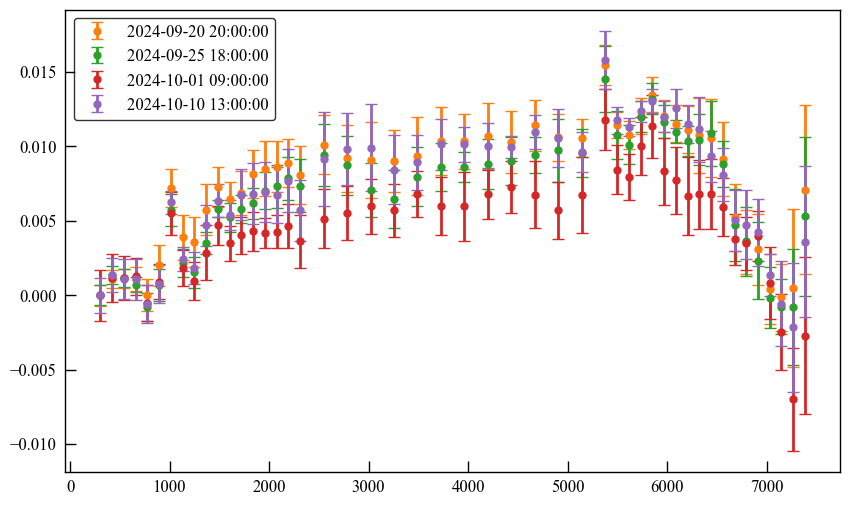

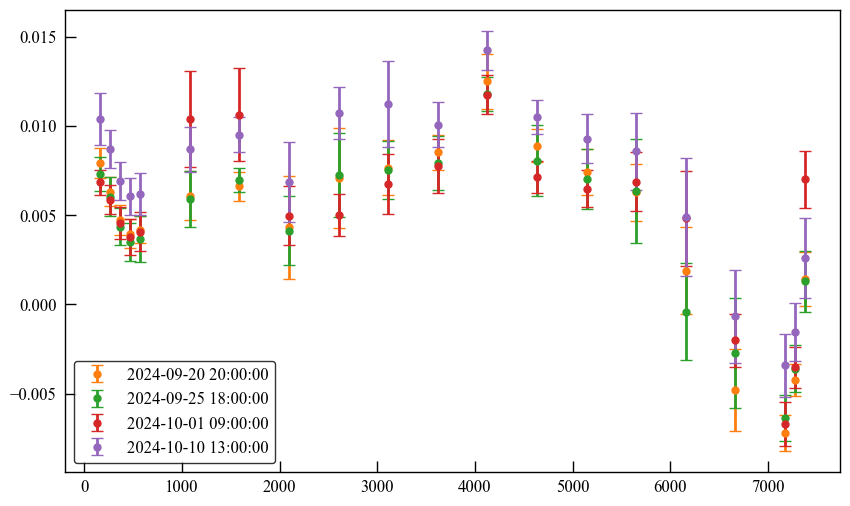

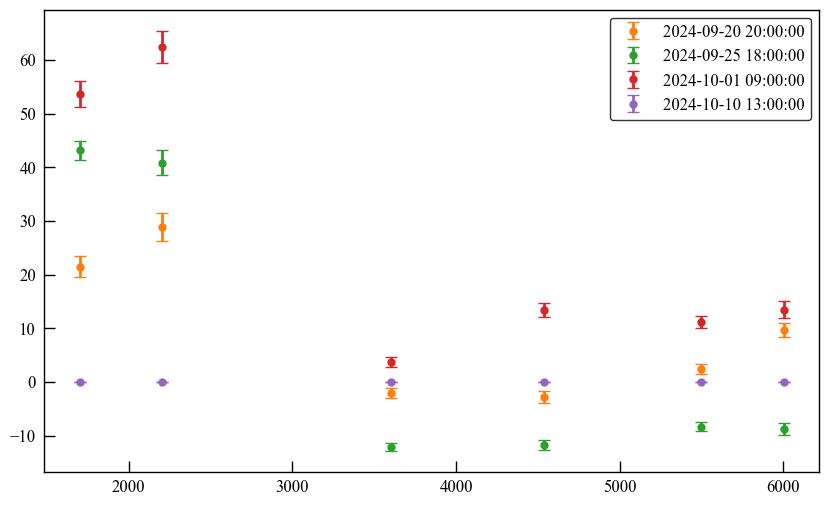

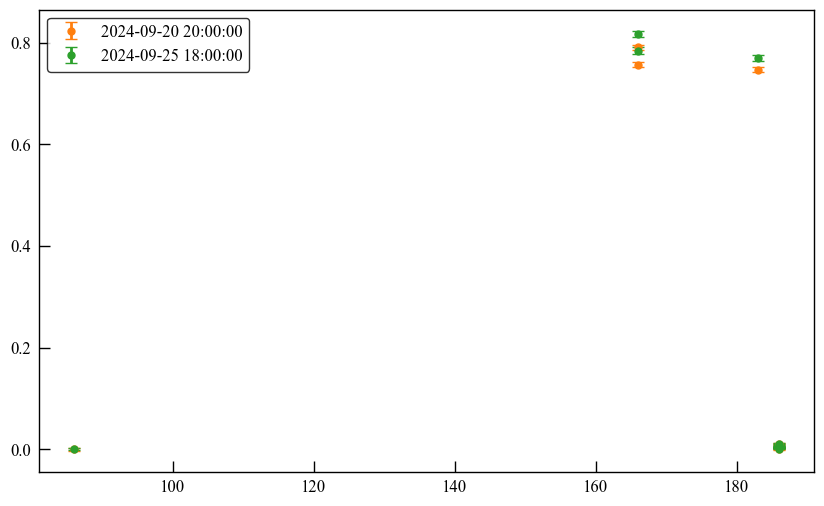

In [88]:
deltat = datetime.timedelta(minutes=15)
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5.5), sharex=True, sharey=True)
axes.plot(tgrad.sensors[39644].data.index.values, tgrad.sensors[39644].data.values, ".", label="TGRAD 39644", color="tab:blue")
axes.set_xlim(pd.Timestamp("2024-09-20 16:00:00"), pd.Timestamp("2024-10-11 11:45:00"))
axes.set_ylim(87.65,87.78)
t1, color1 = pd.Timestamp("2024-09-20 20:00:00"), "tab:orange"
axes.axvline(t1, color=color1, linestyle="--", label=f"{t1}")
t2, color2 = pd.Timestamp("2024-09-25 18:00:00"), "tab:green"
axes.axvline(t2, color=color2, linestyle="--", label=f"{t2}")
t3, color3 = pd.Timestamp("2024-10-1 9:00:00"), "tab:red"
axes.axvline(t3, color=color3, linestyle="--", label=f"{t3}")
t4, color4 = pd.Timestamp("2024-10-10 13:00:00"), "tab:purple"
axes.axvline(t4, color=color4, linestyle="--", label=f"{t4}")
axes2 = axes.twinx()
axes2.plot(ambient.data.index.values, ambient.data.values, "-.", label="Ambient", color="tab:gray")
axes.tick_params(axis='x', rotation=45)


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
profile = tgrad.profiles
zero1 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
zero2 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
profile = tgrad.profiles
zero3 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
profile = tgrad.profiles
zero4 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

####################### APA #######################
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
hawai.makeProfiles(tini=t1, tend=t1 + deltat)
profile = hawai.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

hawai.makeProfiles(tini=t2, tend=t2 + deltat)
profile = hawai.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

hawai.makeProfiles(tini=t3, tend=t3 + deltat)
profile = hawai.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

hawai.makeProfiles(tini=t4, tend=t4 + deltat)
profile = hawai.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
prm.makeProfiles(tini=t1, tend=t1 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

prm.makeProfiles(tini=t2, tend=t2 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

prm.makeProfiles(tini=t3, tend=t3 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

prm.makeProfiles(tini=t4, tend=t4 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
pipe.makeProfiles(tini=t1, tend=t1 + deltat)
profile = pipe.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

pipe.makeProfiles(tini=t2, tend=t2 + deltat)
profile = pipe.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

In [89]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
hawai.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
prm.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pipe.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
apa.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:07<00:00,  6.38sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 111.11sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:03<00:00,  7.74sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 24/24 [00:00<00:00, 120.89sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  6.48sensor/s]
Calibrating PRM Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 6/6 [00:00<00:00, 117.02sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  6.45sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 12/12 [00:00<00:00, 110.65sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00,  8.67sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 16/16 [00:00<00:00, 56.07sensor/s]


/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/1558777642.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/1558777642.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_56809/155

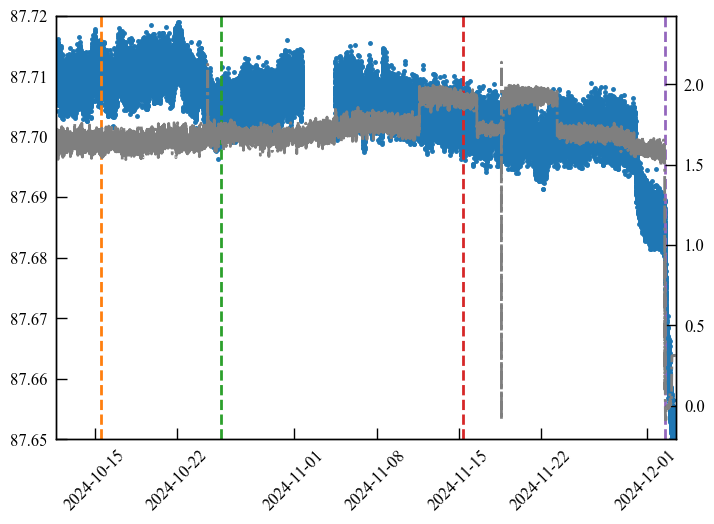

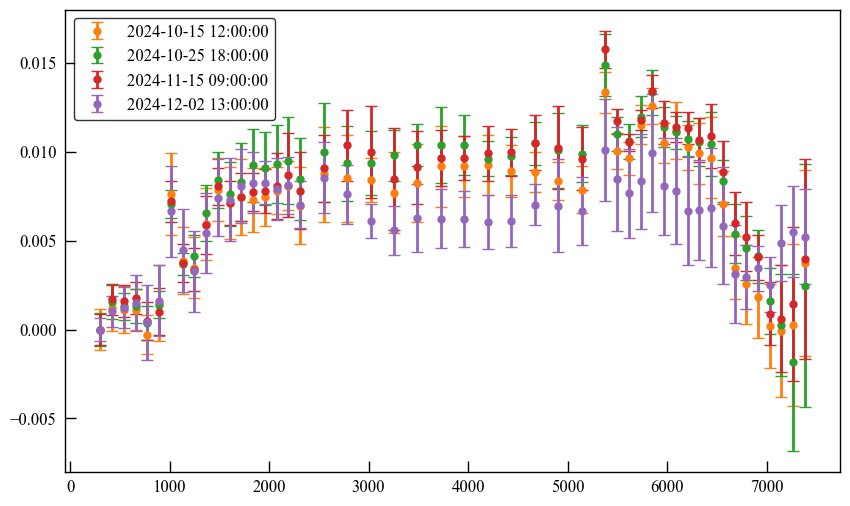

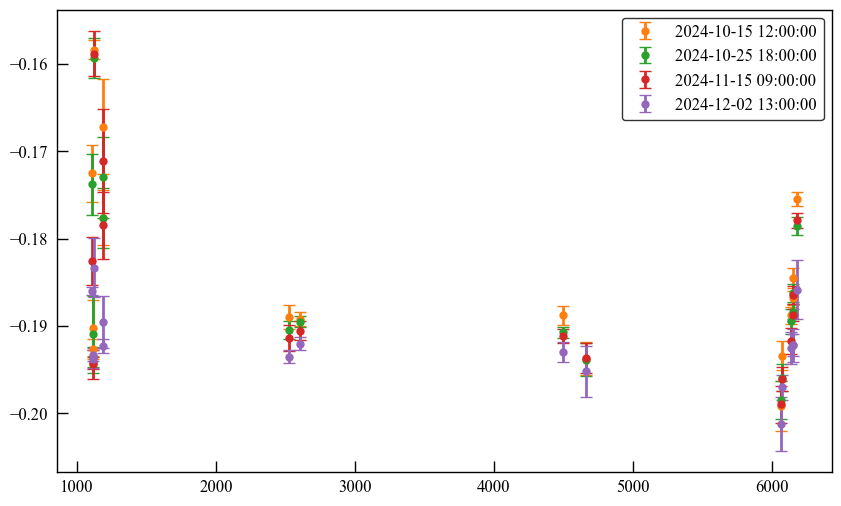

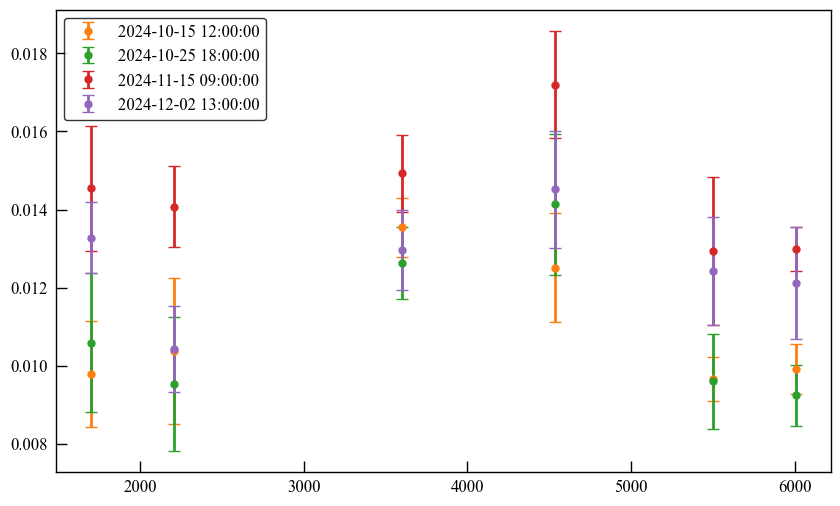

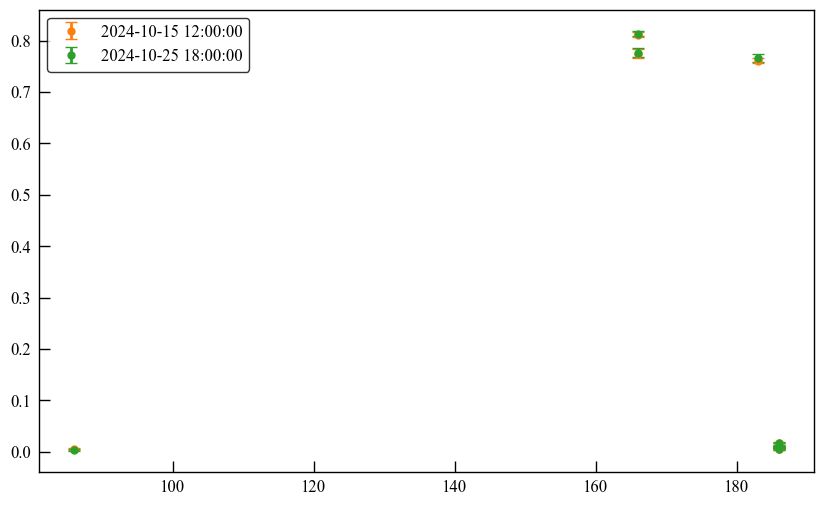

In [90]:
deltat = datetime.timedelta(minutes=15)
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5.5), sharex=True, sharey=True)
axes.plot(tgrad.sensors[39644].data.index.values, tgrad.sensors[39644].data.values, ".", label="TGRAD 39644", color="tab:blue")
axes.set_xlim(pd.Timestamp("2024-10-11 16:00:00"), pd.Timestamp("2024-12-3 11:45:00"))
axes.set_ylim(87.65,87.72)
t1, color1 = pd.Timestamp("2024-10-15 12:00:00"), "tab:orange"
axes.axvline(t1, color=color1, linestyle="--", label=f"{t1}")
t2, color2 = pd.Timestamp("2024-10-25 18:00:00"), "tab:green"
axes.axvline(t2, color=color2, linestyle="--", label=f"{t2}")
t3, color3 = pd.Timestamp("2024-11-15 9:00:00"), "tab:red"
axes.axvline(t3, color=color3, linestyle="--", label=f"{t3}")
t4, color4 = pd.Timestamp("2024-12-02 13:00:00"), "tab:purple"
axes.axvline(t4, color=color4, linestyle="--", label=f"{t4}")
axes2 = axes.twinx()
axes2.plot(ambient.data.index.values, ambient.data.values, "-.", label="Ambient", color="tab:gray")
axes.tick_params(axis='x', rotation=45)


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
profile = tgrad.profiles
zero1 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
zero2 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
profile = tgrad.profiles
zero3 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
profile = tgrad.profiles
zero4 = profile["temp"].loc[(profile["Y"]==305)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

####################### APA #######################
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
apa.makeProfiles(tini=t1, tend=t1 + deltat)
profile = apa.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

apa.makeProfiles(tini=t2, tend=t2 + deltat)
profile = apa.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

apa.makeProfiles(tini=t3, tend=t3 + deltat)
profile = apa.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

apa.makeProfiles(tini=t4, tend=t4 + deltat)
profile = apa.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
prm.makeProfiles(tini=t1, tend=t1 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

prm.makeProfiles(tini=t2, tend=t2 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()

prm.makeProfiles(tini=t3, tend=t3 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero3, yerr=profile["err"].values, fmt='o', label=f"{t3}", color=color3)
axes.legend()

prm.makeProfiles(tini=t4, tend=t4 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero4, yerr=profile["err"].values, fmt='o', label=f"{t4}", color=color4)
axes.legend()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharex=True, sharey=True)
pipe.makeProfiles(tini=t1, tend=t1 + deltat)
profile = pipe.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero1, yerr=profile["err"].values, fmt='o', label=f"{t1}", color=color1)

pipe.makeProfiles(tini=t2, tend=t2 + deltat)
profile = pipe.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - zero2, yerr=profile["err"].values, fmt='o', label=f"{t2}", color=color2)
axes.legend()